# Detector de Spam Bilingüe (Inglés + Español)
## Clasificación automática de mensajes con Machine Learning

**Universidad:** Universidad Nacional de Costa Rica  
**Curso:** Inteligencia Artificial  
**Profesor:** __Pablo_Venegas____________________________  
**Estudiante:** __Angel_Segura____________________________  
**Fecha:** __08-06-26____________________________  

---

## Descripción

Este notebook construye un **clasificador automático de spam** capaz de operar tanto en **inglés** como en **español**. Es **auto-contenido**: descarga sus propios datasets (UCI SMS Spam Collection + dataset público en español, con un seed embebido como respaldo) y no depende de ningún archivo externo.

Se implementan y comparan **tres algoritmos** y se aplican técnicas profesionales de validación:

- **Naive Bayes Multinomial** (Bag of Words)
- **Regresión Logística** (TF-IDF con n-gramas de palabras)
- **Regresión Logística** (TF-IDF con n-gramas de caracteres, ideal cross-lingual)
- **Cross-validation k-fold** para detectar overfitting
- **GridSearchCV** para tuning de hiperparámetros
- **Curva de aprendizaje** para diagnosticar si más datos ayudarían
- **Tuning de threshold** para optimizar Recall (métrica prioritaria)
- **Evaluación por idioma** (EN vs ES) para validar capacidad cross-lingual real

---

## Tabla de contenido

1. Objetivos de aprendizaje  
2. Contexto teórico  
3. Análisis PEAS del agente  
4. Importación de librerías  
5. Descarga del dataset inglés (UCI SMS Spam)  
6. Descarga del dataset español público  
7. Carga unificada en DataFrame  
8. Exploración del corpus  
9. Preprocesamiento del texto  
10. Vectorización (BoW, TF-IDF, char n-grams)  
11. Balanceo del dataset (undersampling)  
12. División train/test  
13. Entrenamiento de los tres modelos  
14. Cross-validation k-fold (anti-overfitting)  
15. GridSearchCV (tuning de hiperparámetros)  
16. Curva de aprendizaje  
17. Tuning de threshold para Recall  
18. Evaluación por idioma (EN vs ES)  
19. Matriz de confusión y análisis de errores  
20. Predicciones sobre mensajes nuevos  
21. Persistencia del modelo  
22. Conclusiones y limitaciones

# 1. Objetivos de aprendizaje

Al finalizar este notebook, podremos:

- Explicar el problema de detección de spam como **clasificación binaria supervisada**.
- Descargar y combinar **datasets reales** desde fuentes públicas.
- Aplicar **preprocesamiento de texto** (limpieza, normalización, stopwords).
- Vectorizar texto con **Bag of Words**, **TF-IDF** y **n-gramas de caracteres**.
- Entrenar **Naive Bayes** y **Regresión Logística** con `sklearn.Pipeline`.
- Validar modelos con **cross-validation k-fold** y detectar overfitting.
- Optimizar hiperparámetros con **GridSearchCV**.
- Diagnosticar la capacidad del modelo con **curva de aprendizaje**.
- Ajustar el **threshold de decisión** para maximizar Recall.
- Validar el modelo **por idioma separado** (cross-lingual real).
- Evaluar con métricas profesionales: Accuracy, Precision, Recall, F1, matriz de confusión.
- Persistir el pipeline completo con `joblib` para inferencia futura.

# 2. Contexto teórico

## 2.1 ¿Qué es el spam?

El **spam** son mensajes no solicitados, generalmente con fines comerciales, fraudulentos o de phishing. Detectarlo automáticamente es un problema clásico de **NLP + ML supervisado**.

## 2.2 Pipeline de un clasificador de texto

```text
Texto crudo → Limpieza → Tokenización → Vectorización → Modelo → {spam, ham}
```

## 2.3 Algoritmos usados

---

### Naive Bayes Multinomial

#### Intuición

Imagina que eres un guardia en la puerta de un edificio. Cada día llegan sobres y tu trabajo es decidir si son spam o no. No puedes leerlos completos — solo ves las palabras escritas en el frente. Después de revisar miles de sobres, aprendes que ciertas palabras (`"GANASTE"`, `"GRATIS"`, `"CLICK AQUÍ"`) aparecen mucho más en spam que en mensajes normales. Eso es exactamente lo que hace Naive Bayes: **aprende de la experiencia qué palabras son señal de spam**, y usa eso para clasificar mensajes nuevos.

#### La pregunta que se hace

Cuando llega un mensaje nuevo con las palabras `["ganaste", "gratis"]`, Naive Bayes compara:

```
P(spam | palabras)   vs   P(ham | palabras)
```

El `|` significa *"dado que"*. Gana la clase con mayor probabilidad.

#### El Teorema de Bayes

Calcular esa probabilidad directamente es imposible (nunca tendrás suficientes ejemplos de cada combinación de palabras). Por eso Bayes da la vuelta a la pregunta:

$$P(\text{spam} \mid \text{palabras}) = \frac{P(\text{palabras} \mid \text{spam}) \cdot P(\text{spam})}{P(\text{palabras})}$$

| Término | Significado |
|---|---|
| $P(\text{spam})$ | ¿Qué fracción de mensajes en el entrenamiento eran spam? |
| $P(\text{palabras} \mid \text{spam})$ | Si el mensaje es spam, ¿qué tan probable es ver estas palabras? |
| $P(\text{palabras})$ | Denominador igual para spam y ham → se cancela en la comparación |

#### El supuesto "Naive" (ingenuo)

Para calcular $P(\text{"ganaste", "gratis"} \mid \text{spam})$, el algoritmo asume que **cada palabra es independiente de las demás**. Eso permite multiplicar:

$$P(\text{"ganaste"} \mid \text{spam}) \times P(\text{"gratis"} \mid \text{spam})$$

Es una simplificación falsa en la realidad (las palabras sí se relacionan), pero funciona sorprendentemente bien en la práctica.

#### Ejemplo con números

**Datos de entrenamiento:** 100 mensajes spam, 200 ham.

| Palabra | Aparece en spam | Aparece en ham |
|---|---|---|
| "ganaste" | 80 | 2 |
| "gratis" | 70 | 5 |

```
P("ganaste" | spam) = 80/100 = 0.80     P("ganaste" | ham) = 2/200 = 0.01
P("gratis"  | spam) = 70/100 = 0.70     P("gratis"  | ham) = 5/200 = 0.025
P(spam) = 100/300 = 0.33                P(ham) = 200/300 = 0.67

Score spam = 0.80 × 0.70 × 0.33 = 0.185
Score ham  = 0.01 × 0.025 × 0.67 = 0.000167

→ Score spam >> Score ham  →  SPAM ✓
```

#### Suavizado de Laplace (α = 1.0)

**El problema:** si una palabra nunca apareció en spam durante el entrenamiento, su probabilidad es 0. Al multiplicar, **un solo cero destruye toda la evidencia acumulada** — no importa cuántas otras palabras griten "spam".

**La solución:** Laplace agrega 1 a cada conteo para que ninguna probabilidad sea exactamente cero:

$$P(\text{palabra} \mid \text{clase}) = \frac{\text{conteo} + \alpha}{\text{total} + \alpha \times V}$$

Donde $V$ es el tamaño del vocabulario (palabras únicas). Con `alpha=0` volvería el problema del cero; con `alpha` mayor se suaviza más agresivamente (útil con pocos datos).

```python
MultinomialNB(alpha=1.0)  # ← el 1.0 es el parámetro de Laplace
```

---

### Regresión Logística — Modelo 2: TF-IDF sobre palabras

#### Intuición

A diferencia de Naive Bayes (que cuenta probabilidades), la Regresión Logística **aprende un peso $w$ para cada palabra del vocabulario**. Una palabra muy asociada a spam (como "ganaste") obtiene un peso positivo alto; una palabra de mensajes normales (como "reunión") obtiene un peso negativo.

#### La función sigmoide

Suma todos los pesos de las palabras presentes en el mensaje y aplica la función sigmoide, que convierte cualquier número real en una probabilidad entre 0 y 1:

$$P(\text{spam} \mid x) = \frac{1}{1 + e^{-(w^\top x + b)}}$$

Si el resultado supera el **threshold** (por defecto 0.5), clasifica como spam.

#### Vectorización: TF-IDF con n-gramas de palabras

Este modelo recibe como entrada **vectores TF-IDF de palabras** con `ngram_range=(1,2)`:

- **TF (Term Frequency):** qué tan seguido aparece una palabra en *este* mensaje.
- **IDF (Inverse Document Frequency):** penaliza palabras que aparecen en casi todos los mensajes (como "el", "de") porque aportan poca información para distinguir spam de ham.
- **N-gramas (1,2):** considera palabras individuales (`"ganaste"`) Y pares consecutivos (`"has ganado"`), capturando frases cortas que son señal de spam.
 

### Regresión Logística — Modelo 3: TF-IDF sobre caracteres (cross-lingual)

#### ¿Por qué un tercer modelo?

El Modelo 3 conserva la **Regresión Logística**, pero **cambia la forma de procesar el texto**: en lugar de palabras completas usa **n-gramas de caracteres** (trozos de 3–5 letras). Ese cambio trae ventajas: es más **robusto a errores de escritura y ofuscación** (capta *gan* aunque esté escrito *g4n*) y **transfiere mejor entre idiomas**, porque reconoce subpatrones compartidos sin depender de que la palabra exacta esté en el vocabulario.
   
#### Resumen comparativo de los tres modelos

| Modelo | Vectorización | Fortaleza | Debilidad |
|---|---|---|---|
| Naive Bayes | BoW (conteos) | Rápido, interpretable, poco dato | Asume independencia entre palabras |
| Logistic (palabras) | TF-IDF (1,2)-gramas | Pesa features, maneja desbalance | Depende del idioma del vocabulario |
| Logistic (caracteres) | TF-IDF char_wb (3,5) | Cross-lingual, robusto a typos | Vocabulario más grande, más lento |

---

## 2.4 Métrica prioritaria: Recall sobre spam

$$\text{Recall} = \frac{TP}{TP + FN} \qquad \text{Precision} = \frac{TP}{TP + FP}$$

### Falso negativo y falso positivo

| Término | Qué ocurre | Ejemplo |
|---|---|---|
| **Falso negativo** (FN) | Spam que el modelo clasifica como ham | Un email de phishing llega a tu bandeja principal |
| **Falso positivo** (FP) | Ham que el modelo clasifica como spam | Un correo importante va a la carpeta spam |
 
### El tradeoff Precision-Recall

No puedes maximizar Recall y Precision al mismo tiempo — existe un tradeoff directo controlado por el **threshold**:

```
Threshold bajo  →  más mensajes clasificados como spam
                →  Recall sube  (detecta más spam real)
                →  Precision baja (bloquea más ham por error)

Threshold alto  →  solo clasifica como spam cuando está muy seguro
                →  Precision sube (pocos falsos positivos)
                →  Recall baja  (deja pasar más spam)
```

### Decisión de este proyecto

Este clasificador está orientado a **seguridad** (phishing, fraude). Por eso priorizamos **Recall**: preferimos bloquear algún ham ocasional antes que dejar pasar un mensaje malicioso. El threshold óptimo se ajusta en la sección 17 para maximizar Recall manteniendo Precision ≥ 0.85.

> **Nota importante:** esta decisión no la toma el algoritmo. La toma el equipo según el negocio y el costo real de cada tipo de error.

 

# 3. Análisis PEAS del agente

El framework **PEAS** define formalmente a un agente inteligente: qué mide su éxito, en qué entorno opera, qué acciones puede tomar y qué información percibe.

| Componente | Definición | ¿Por qué esta elección? |
|------------|-----------|------------------------|
| **P — Performance** | Accuracy, Precision, Recall, F1. Prioridad: Recall sobre clase `spam` (>90%). | Accuracy sola engaña en datasets desbalanceados — un modelo que siempre predice "ham" obtiene 86% de accuracy sin detectar nada. Priorizamos Recall porque en un contexto de seguridad (phishing, fraude), dejar pasar spam es más costoso que bloquear un ham por error. |
| **E — Environment** | Mensajes en inglés o español, con HTML, URLs, números y errores ortográficos. | El entorno define los datos reales que el agente verá en producción. Incluimos HTML y URLs porque el spam las usa deliberadamente. El soporte bilingüe responde a usuarios hispanohablantes que también reciben phishing. Los errores ortográficos son una táctica deliberada para evadir filtros simples. |
| **A — Actuators** | Etiqueta `spam`/`ham` + nivel de confianza ∈ [0,1] + probabilidades por clase. | No basta con la etiqueta binaria. El nivel de confianza permite decisiones más finas en sistemas reales: P(spam)=0.51 podría ir a revisión humana, mientras que P(spam)=0.99 se bloquea automáticamente. |
| **S — Sensors** | El texto crudo del mensaje. | El agente solo percibe contenido textual. |

---

| Característica | Valor | ¿Por qué? |
|---|---|---|
| **Observable** | Totalmente | El agente recibe el mensaje completo, no fragmentos |
| **Agentes** | Un solo agente | No hay competencia ni cooperación con otros clasificadores |
| **Determinístico** | Determinístico | El mismo texto produce siempre la misma predicción |
| **Secuencial/Episódico** | Episódico | Cada mensaje se clasifica de forma independiente; la clasificación de uno no afecta al siguiente |
| **Dinámico/Estático** | Estático | El entorno no cambia mientras el agente decide (aunque el spam evoluciona con el tiempo, el modelo no se actualiza en tiempo real) |

**Tipo de agente:** *Model-based* — aprende una representación interna del mundo (pesos de palabras o probabilidades) durante el entrenamiento, y luego la usa en inferencia sin aprender de nuevos ejemplos en producción.

## 3.1 Formalización de variables de entrada y salida

El problema se modela como **clasificación binaria supervisada**. El agente aprende una función

$$f:\ \mathcal{X} \rightarrow \mathcal{Y}$$

donde la entrada es el texto crudo del mensaje y la salida es una etiqueta más una probabilidad asociada.

| | Variable | Tipo | Dominio | Descripción |
|---|---|---|---|---|
| **Entrada** $\mathcal{X}$ | `text` | Texto libre (string) | Cadena Unicode de longitud variable (EN/ES) | Contenido crudo del mensaje (asunto/cuerpo), con HTML, URLs, números y emojis |
| **Salida** $\mathcal{Y}$ | `label` | Categórica binaria | $\{\texttt{spam},\ \texttt{ham}\}$ | Clase predicha del mensaje |
| **Salida** (auxiliar) | `P(spam)` | Continua | $[0, 1]$ | Probabilidad estimada de spam; se compara contra el *threshold* óptimo para decidir la etiqueta |

- **Variable objetivo (target):** `label`.
- **Codificación interna:** `spam → 1`, `ham → 0` para el cálculo de métricas.
- **Regla de decisión:** $\hat{y} = \texttt{spam}$ si $P(\text{spam}\mid \text{texto}) \ge t^{*}$, donde $t^{*}$ es el threshold calibrado en la Sección 17 (no necesariamente 0.5).

# 4. Importación de librerías

In [1]:
%matplotlib inline
import io
import re
import csv
import html
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
    learning_curve,
)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
)

import joblib

warnings.filterwarnings("ignore", category=UserWarning)

try:
    stopwords.words("english")
    stopwords.words("spanish")
except LookupError:
    nltk.download("stopwords", quiet=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


# 5. Descarga del dataset inglés — UCI SMS Spam Collection

Bajamos el dataset oficial de UCI: ~5,574 SMS etiquetados como `spam`/`ham`.  
Fuente: <https://archive.ics.uci.edu/dataset/228/sms+spam+collection>

### Caché de reproducibilidad offline

Antes de descargar nada, comprobamos si existe `data/corpus.parquet`. Si está, cargamos el corpus directamente desde disco y **omitimos todas las descargas** — así el notebook es reproducible sin conexión a internet. La primera ejecución descarga los datasets y guarda el caché automáticamente.

In [2]:
# --- Caché de reproducibilidad offline ---
# Si data/corpus.parquet ya existe, cargamos el corpus desde disco y NO descargamos
# nada de internet. Esto permite evaluar el notebook sin conexión.
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
CORPUS_CACHE = DATA_DIR / "corpus.parquet"
USE_CACHE = CORPUS_CACHE.exists()

if USE_CACHE:
    df = pd.read_parquet(CORPUS_CACHE)
    print(f"[CACHE] Corpus cargado desde {CORPUS_CACHE} — {len(df):,} mensajes. Se omiten las descargas.")
else:
    print("[CACHE] No hay caché local; se descargarán los datasets desde internet "
          "y se guardará corpus.parquet al final.")

[CACHE] Corpus cargado desde data/corpus.parquet — 6,290 mensajes. Se omiten las descargas.


In [3]:
# Cascada de fuentes para el SMS Spam Collection.
# La URL oficial de UCI a veces tiene certificado SSL expirado; por eso probamos varios mirrors.
SMS_SOURCES = [
    {
        "name": "GitHub mirror (justmarkham)",
        "url": "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv",
        "format": "tsv",
    },
    {
        "name": "UCI oficial",
        "url": "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip",
        "format": "zip",
    },
    {
        "name": "HuggingFace mirror (ucirvine/sms_spam)",
        "url": "https://huggingface.co/datasets/ucirvine/sms_spam/resolve/main/plain_text/train-00000-of-00001.parquet",
        "format": "parquet",
    },
]


def _parse_zip(content):
    with zipfile.ZipFile(io.BytesIO(content)) as z:
        target = [n for n in z.namelist() if "SMSSpamCollection" in n][0]
        with z.open(target) as f:
            return pd.read_csv(
                f, sep="\t", names=["label", "text"],
                quoting=csv.QUOTE_NONE, encoding="utf-8",
                on_bad_lines="skip",
            )


def _parse_parquet(content):
    df = pd.read_parquet(io.BytesIO(content))
    if "sms" in df.columns:
        df = df.rename(columns={"sms": "text"})
    if df["label"].dtype != object:
        df["label"] = df["label"].map({0: "ham", 1: "spam"})
    return df[["label", "text"]]


def _parse_tsv(content):
    return pd.read_csv(
        io.BytesIO(content), sep="\t", names=["label", "text"],
        quoting=csv.QUOTE_NONE, encoding="utf-8",
        on_bad_lines="skip",
    )


_PARSERS = {"zip": _parse_zip, "parquet": _parse_parquet, "tsv": _parse_tsv}


def download_sms_spam():
    """Intenta varias fuentes hasta que una funcione. Tolerante a fallos SSL."""
    last_error = None
    for src in SMS_SOURCES:
        try:
            print(f"  Intentando: {src['name']} ...")
            try:
                resp = requests.get(src["url"], timeout=30)
                resp.raise_for_status()
            except requests.exceptions.SSLError:
                print("    [WARN] SSL fallo, reintentando con verify=False")
                resp = requests.get(src["url"], timeout=30, verify=False)
                resp.raise_for_status()
            df = _PARSERS[src["format"]](resp.content)
            df["label"] = df["label"].astype(str).str.lower()
            df = df[df["label"].isin(["ham", "spam"])].copy()
            df["lang"] = "en"
            print(f"  [OK] {len(df):,} mensajes desde {src['name']}")
            return df[["text", "label", "lang"]].reset_index(drop=True)
        except Exception as exc:
            last_error = exc
            print(f"    [FAIL] {type(exc).__name__}: {str(exc)[:80]}")
    raise RuntimeError(f"Todas las fuentes fallaron. Ultimo error: {last_error}")


# Solo descargamos si NO hay corpus cacheado (ver celda de caché previa).
if not USE_CACHE:
    print("Descargando SMS Spam Collection ...")
    sms_en = download_sms_spam()
    print(f"\nDataset ingles cargado: {len(sms_en):,} mensajes")
    print(sms_en["label"].value_counts())
    display(sms_en.head())
else:
    print("[CACHE] Descarga del dataset ingles OMITIDA (se usara corpus.parquet).")

[CACHE] Descarga del dataset ingles OMITIDA (se usara corpus.parquet).


# # 6. Descarga del dataset español
  
  El soporte en español combina **dos fuentes de español genuino**:
 
  1. **Nativo** — `softecapps/spam_ham_spanish` (~1 200 mensajes escritos directamente en español, balanceados ~52 % spam). Aporta spam español real, no traducción.
  2. **Seed local** — 61 mensajes de phishing hispanohablante embebidos (siempre disponibles).
 
  > **Nota metodológica (anti-fuga).** En una versión previa se incluía una tercera fuente *traducida* (`dbarbedillo`, el UCI inglés traducido al español). Se **descartó**: eran traducciones automáticas de los **mismos** mensajes UCI que ya están en inglés. Como el de-duplicado es por texto exacto, el original en inglés y su traducción en español coexistían, y el split aleatorio podía mandar un mensaje a *train* (EN) y su gemelo a *test* (ES) → **fuga cross-lingual** que inflaba artificialmente las métricas (sobre todo la evaluación por idioma de la Sección 18). Usar solo español genuino hace que el número cross-lingual sea **honesto**.
 
  Cada fuente tiene *fallback*: si una falla en la descarga, se omite y el corpus se arma con las disponibles.


In [4]:
# Dataset español = NATIVO + SEED (solo español genuino).
# Se descartó la fuente "traducida" (dbarbedillo): eran traducciones automáticas de los
# MISMOS mensajes UCI en inglés. Al coexistir el original EN y su traducción ES, el split
# aleatorio metía un mensaje en train (EN) y su gemelo en test (ES) -> fuga cross-lingual
# que inflaba las métricas. Usamos solo español genuino para una evaluación honesta.

# 1) Nativo: softecapps/spam_ham_spanish (spam escrito directamente en español).
SPANISH_NATIVE_BASE = (
    "https://huggingface.co/datasets/softecapps/spam_ham_spanish/resolve/main/"
)

# 2) Seed embebido — phishing local hispanohablante real (siempre disponible).
SPANISH_SEED = [
    ("spam", "FELICIDADES! Has ganado un iPhone 15. Reclama ahora en http://bit.ly/premio-iphone"),
    ("spam", "URGENTE: Tu cuenta bancaria sera suspendida. Verifica tus datos en http://bbva-seguro.co"),
    ("spam", "Has sido seleccionado para un prestamo de 50000 sin requisitos. Llama YA al 800 555 1234"),
    ("spam", "Promo exclusiva!!! 90 por ciento de descuento en Amazon. Compra ahora http://amazon-ofertas.net"),
    ("spam", "GANA DINERO desde casa hasta 5000 semanales. Envia HOLA al 4040"),
    ("spam", "Tu paquete de DHL no pudo ser entregado. Confirma direccion en http://dhl-rastreo.info"),
    ("spam", "Netflix tu suscripcion vencio. Actualiza tu metodo de pago aqui http://netflix-pago.cc"),
    ("spam", "Banco Santander detectamos un acceso sospechoso. Verifica tu identidad en http://santander-acceso.com"),
    ("spam", "Tu factura de CFE esta vencida. Paga en linea o se cortara la luz en http://cfe-pagos.tk"),
    ("spam", "Loteria Nacional tu numero salio premiado con 100000 EUR. Reclama: premio@loteria-es.org"),
    ("spam", "Premio Coca-Cola ganaste un viaje todo pagado a Cancun. Confirma datos en http://cocacola-promo.com"),
    ("spam", "Reactiva tu cuenta de WhatsApp antes de 24h o sera eliminada en http://whatsapp-verifica.net"),
    ("spam", "Tu tarjeta Visa fue bloqueada por seguridad. Desbloquea en http://visa-soporte.cc"),
    ("spam", "GRATIS Curso de ingles avanzado en 7 dias. Cupos limitados en http://aprende-rapido.online"),
    ("spam", "SAT tienes una devolucion pendiente de 8400. Ingresa CURP en http://sat-devoluciones.mx-info.com"),
    ("spam", "Sorteo Mercado Libre ganaste 25000 MXN en compras. Reclama en http://meli-sorteo.win"),
    ("spam", "Empleo desde casa 1500 al dia. Sin experiencia. WhatsApp +52 55 1234 5678"),
    ("spam", "Tu cuenta de Instagram sera eliminada por copyright. Apela aqui en http://insta-soporte.help"),
    ("spam", "Inversion garantizada 30 por ciento mensual en cripto. Empieza con solo 100 en http://cripto-rico.net"),
    ("spam", "Tu Spotify premium expira hoy. Renueva con un click en http://spotify-renovar.cc"),
    ("spam", "BBVA Mexico nuevo intento de acceso desde Rusia. Bloquea aqui http://bbva-seguridad.tk"),
    ("spam", "Tu pedido de Aliexpress requiere pago de aduana de 4 USD. Paga aqui http://aduana-mx.online"),
    ("spam", "Tu DNI electronico expiro. Renueva en linea en http://dni-renovar.gob-info.es"),
    ("spam", "Has sido elegido para participar en estudio remunerado. 200 EUR por encuesta http://encuestas-pagadas.cc"),
    ("spam", "GANA 1000 EUROS AHORA Responde este SMS con la palabra GANAR"),
    ("spam", "Apple Pay tu cuenta requiere verificacion urgente. Confirma en http://apple-id-verify.org"),
    ("spam", "Banco Galicia detectamos compras sospechosas. Cancela en http://galicia-seguro.com.ar"),
    ("spam", "Tu factura de Movistar esta vencida. Paga aqui o se suspendera tu linea http://movistar-pago.tk"),
    ("spam", "Ultima oportunidad 80 por ciento off en zapatos Nike y Adidas. Compra en http://outlet-deportivo.cc"),
    ("spam", "Felicidades Has ganado un cupon de 500 en Walmart. Reclama en http://walmart-cupones.com"),
    ("ham", "Hola como estas Te paso a buscar a las 7 de la noche para ir al cine"),
    ("ham", "Recordatorio junta de equipo manana a las 10am en la sala 3"),
    ("ham", "Mama dice que llegues temprano porque tenemos cena familiar"),
    ("ham", "Te mando el documento revisado dime si necesitas cambios antes del viernes"),
    ("ham", "Gracias por la ayuda con el codigo ya logre que compile"),
    ("ham", "Hoy salgo tarde de la oficina no me esperen para cenar"),
    ("ham", "Pasame la receta del flan que hiciste el domingo estaba delicioso"),
    ("ham", "Confirmo asistencia a la reunion del jueves llevo el reporte impreso"),
    ("ham", "El nino tiene fiebre voy a llevarlo al medico esta tarde"),
    ("ham", "Quedamos en el bar de siempre a las 9 Avisame si cambias de plan"),
    ("ham", "Buenos dias le envio el presupuesto para la remodelacion segun lo platicado"),
    ("ham", "Acabo de llegar a la oficina en 10 minutos te marco para revisar el contrato"),
    ("ham", "Feliz cumpleanos hermanito que cumplas muchos mas Un abrazo enorme"),
    ("ham", "El profesor cambio la fecha del examen para el martes 15"),
    ("ham", "Estoy en el supermercado quieres que te lleve algo"),
    ("ham", "El partido empieza a las 8 vienes a verlo a la casa"),
    ("ham", "Ya envie el correo al cliente con la cotizacion actualizada"),
    ("ham", "Pase por farmacia las pastillas que pediste no las tenian"),
    ("ham", "El vuelo aterriza a las 6 45am tomo un Uber al hotel"),
    ("ham", "Que tal el viaje Manda fotos cuando puedas"),
    ("ham", "Necesito que me cubras la guardia del sabado te debo una"),
    ("ham", "Encontre el libro que querias en la biblioteca te lo presto el lunes"),
    ("ham", "El plomero viene manana entre 9 y 11 puedes recibirlo"),
    ("ham", "Adjunto las minutas de la reunion del miercoles para tu revision"),
    ("ham", "Nos juntamos en mi casa para estudiar el examen de calculo"),
    ("ham", "Ya pague la luz te paso comprobante por whatsapp"),
    ("ham", "El doctor dijo que esta todo bien solo descanso por una semana"),
    ("ham", "Me encanto la pelicula gracias por recomendarmela"),
    ("ham", "Voy a estar fuera de la oficina del 5 al 12 cualquier urgencia escribe a Carlos"),
    ("ham", "Acuerdate de comprar pan cuando regreses ya casi no queda"),
    ("ham", "Profe podriamos revisar la tarea 4 en la asesoria de manana"),
]


def download_spanish_native():
    """Nativo: spam escrito directamente en español (softecapps/spam_ham_spanish)."""
    print("  Descargando dataset nativo (softecapps) ...")
    try:
        parts = []
        for fname in ("train.csv", "test.csv"):
            d = pd.read_csv(SPANISH_NATIVE_BASE + fname)
            d.columns = [c.strip().lower() for c in d.columns]  # ' tipo' -> 'tipo'
            parts.append(d[["mensaje", "tipo"]])
        d = pd.concat(parts, ignore_index=True)
        d = d.rename(columns={"mensaje": "text", "tipo": "label"})
        d["label"] = d["label"].astype(str).str.strip().str.lower()
        d = d[d["label"].isin(["ham", "spam"])].dropna(subset=["text"])
        d = d[d["text"].str.strip().str.len() > 0]
        d["lang"] = "es"
        print(f"    [OK] {len(d):,} mensajes NATIVOS (spam ratio {(d.label=='spam').mean():.0%})")
        return d[["text", "label", "lang"]].reset_index(drop=True)
    except Exception as exc:
        print(f"    [FAIL nativo] {type(exc).__name__}: {str(exc)[:90]}")
        return None


if not USE_CACHE:
    print("Cargando dataset espanol (2 fuentes: nativo + seed) ...")
    seed_df = pd.DataFrame([{"text": t, "label": l, "lang": "es"} for l, t in SPANISH_SEED])
    _nat = download_spanish_native()
    if _nat is not None:
        _nat["source"] = "es_nativo"
    seed_df["source"] = "es_seed"
    fuentes = [f for f in [_nat, seed_df] if f is not None and len(f) > 0]
    sms_es = pd.concat(fuentes, ignore_index=True)
    print(f"\nDataset espanol combinado = {len(sms_es):,} mensajes ({len(fuentes)} fuentes)")
    print(sms_es["label"].value_counts())
    display(sms_es.head())
else:
    print("[CACHE] Descarga del dataset espanol OMITIDA (se usara corpus.parquet).")


[CACHE] Descarga del dataset espanol OMITIDA (se usara corpus.parquet).


# 7. Carga unificada en DataFrame

Unimos ambos datasets en un solo DataFrame con columnas `text`, `label`, `lang`. Eliminamos duplicados para evitar inflar el modelo con datos repetidos.

In [5]:
# Carga unificada. Si venimos de caché (USE_CACHE=True), df ya está cargado desde disco.
if not USE_CACHE:
    df = pd.concat([sms_en, sms_es], ignore_index=True)
    df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)
    df = df[df["text"].notna() & (df["text"].str.strip().str.len() > 0)].reset_index(drop=True)
    # Persistimos el corpus para reproducibilidad offline (evaluación sin internet).
    df.to_parquet(CORPUS_CACHE, index=False)
    print(f"[CACHE] Corpus guardado en {CORPUS_CACHE}")

print(f"Total de mensajes (sin duplicados): {len(df):,}")
df.sample(5, random_state=RANDOM_STATE)

Total de mensajes (sin duplicados): 6,290


,text,label,lang,source
3599,Please protect yourself from e-threats. SIB ne...,ham,en,NaN
1163,Ok... C ya...,ham,en,NaN
318,Hey... Why dont we just go watch x men and hav...,ham,en,NaN
1669,There bold 2 &lt;#&gt; . Is that yours,ham,en,NaN
1268,Designation is software developer and may be s...,ham,en,NaN


# 8. Exploración del corpus

In [6]:
distribution = df.groupby(["lang", "label"]).size().unstack(fill_value=0)
print("Distribución de clases por idioma:")
print(distribution)

spam_ratio = (df["label"] == "spam").mean()
print(f"\nProporción global de spam: {spam_ratio:.2%}")
print(f"Proporción global de ham:  {1 - spam_ratio:.2%}")

Distribución de clases por idioma:
label   ham  spam
lang             
en     4518   653
es      540   579

Proporción global de spam: 19.59%
Proporción global de ham:  80.41%


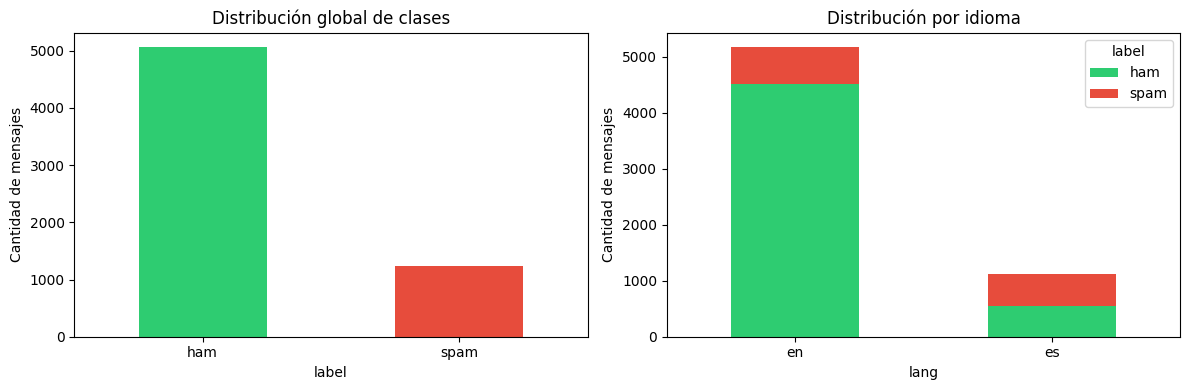

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["label"].value_counts().plot(kind="bar", ax=axes[0], color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Distribución global de clases")
axes[0].set_ylabel("Cantidad de mensajes")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
distribution.plot(kind="bar", stacked=True, ax=axes[1], color=["#2ecc71", "#e74c3c"])
axes[1].set_title("Distribución por idioma")
axes[1].set_ylabel("Cantidad de mensajes")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

Longitud promedio de mensajes (caracteres) por clase:
            mean   50%   min    max
label                              
ham    67.888493  50.0   2.0  910.0
spam   94.486201  86.0  13.0  223.0


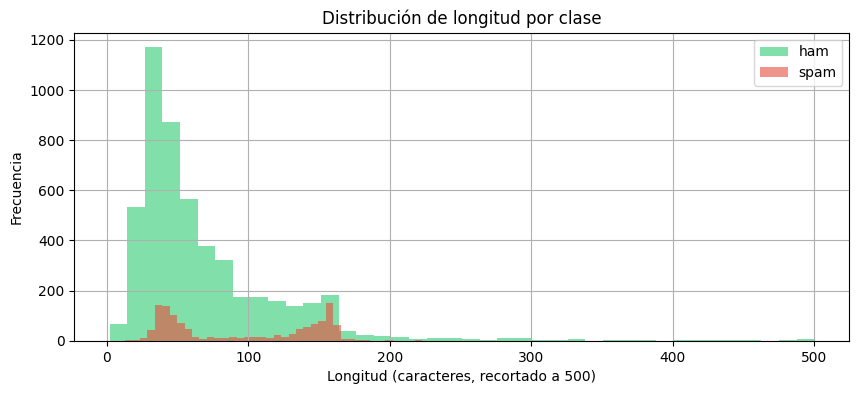

In [8]:
df["length"] = df["text"].str.len()
print("Longitud promedio de mensajes (caracteres) por clase:")
print(df.groupby("label")["length"].describe()[["mean", "50%", "min", "max"]])

fig, ax = plt.subplots(figsize=(10, 4))
for label, color in [("ham", "#2ecc71"), ("spam", "#e74c3c")]:
    df.loc[df["label"] == label, "length"].clip(upper=500).hist(
        bins=40, alpha=0.6, label=label, color=color, ax=ax
    )
ax.set_xlabel("Longitud (caracteres, recortado a 500)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de longitud por clase")
ax.legend()
plt.show()

### Lectura del resultado

El corpus está **desbalanceado** (~20 % spam) en ambos idiomas, y el spam tiende a ser **más largo** que el ham (media ~94 vs ~68 caracteres). Por eso conviene **balancear** y no fiarse de la accuracy. El español está sub-representado (~1 100 mensajes frente a ~5 100 en inglés), así que añadimos un vectorizador de **caracteres** que transfiere mejor entre idiomas.

# 9. Preprocesamiento del texto

Limpieza paso a paso:

1. Decodificar entidades HTML.
2. Eliminar etiquetas HTML.
3. Reemplazar URLs, emails y números por **tokens especiales** (preservan la señal sin sobreajustar al string exacto).
4. Pasar a minúsculas.
5. Eliminar caracteres no alfabéticos (preservando tildes y `ñ`).
6. Normalizar espacios en blanco.

In [9]:
URL_RE = re.compile(r"https?://\S+|www\.\S+")
EMAIL_RE = re.compile(r"\S+@\S+")
NUMBER_RE = re.compile(r"\b\d+(?:[.,]\d+)*\b")
HTML_TAG_RE = re.compile(r"<[^>]+>")
NON_WORD_RE = re.compile(r"[^\wáéíóúñü\s-]", flags=re.IGNORECASE)
WHITESPACE_RE = re.compile(r"\s+")

STOPWORDS = set(stopwords.words("english")) | set(stopwords.words("spanish"))
print(f"Stopwords combinadas (EN + ES): {len(STOPWORDS):,}")


def clean_text(text):
    """Normaliza un texto crudo aplicando todas las reglas de limpieza."""
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = HTML_TAG_RE.sub(" ", text)
    text = URL_RE.sub(" __url__ ", text)
    text = EMAIL_RE.sub(" __email__ ", text)
    text = NUMBER_RE.sub(" __num__ ", text)
    text = text.lower()
    text = NON_WORD_RE.sub(" ", text)
    text = WHITESPACE_RE.sub(" ", text).strip()
    return text


ejemplos = df.sample(3, random_state=RANDOM_STATE)
for _, row in ejemplos.iterrows():
    print(f"[{row['label'].upper():4} {row['lang'].upper()}] Original: {row['text'][:100]!r}")
    print(f"              Limpio:   {clean_text(row['text'])[:100]!r}")
    print()

Stopwords combinadas (EN + ES): 504
[HAM  EN] Original: 'Please protect yourself from e-threats. SIB never asks for sensitive information like Passwords,ATM/'
              Limpio:   'please protect yourself from e-threats sib never asks for sensitive information like passwords atm s'

[HAM  EN] Original: 'Ok... C ya...'
              Limpio:   'ok c ya'

[HAM  EN] Original: 'Hey... Why dont we just go watch x men and have lunch... Haha '
              Limpio:   'hey why dont we just go watch x men and have lunch haha'



In [10]:
df["text_clean"] = df["text"].apply(clean_text)
df = df[df["text_clean"].str.len() > 0].reset_index(drop=True)
print(f"Mensajes válidos tras limpieza: {len(df):,}")

Mensajes válidos tras limpieza: 6,289


# 10. Vectorización (BoW, TF-IDF, char n-grams)

El modelo necesita números, no texto. Usaremos tres estrategias:

| Estrategia | Fórmula | Ventaja |
|-----------|---------|---------|
| **Bag of Words** | conteo de cada palabra | rápido, interpretable |
| **TF-IDF (palabras)** | $tf \cdot \log(N/df)$ | penaliza palabras muy comunes |
| **TF-IDF char_wb** | n-gramas de caracteres (3,5) | robusto cross-lingual y a typos |

Cada vectorizador se aplica **dentro de un `Pipeline`** en la siguiente sección, para evitar data leakage durante la validación cruzada.

# 11. Balanceo del dataset

El corpus combinado tiene **~20% spam vs ~80% ham**, un desbalance fuerte. Con esta proporción, un modelo que prediga siempre "ham" obtiene ~80% de accuracy sin aprender nada.

Para mitigarlo aplicamos **undersampling de la clase mayoritaria (ham)**: tomamos una muestra aleatoria de ham con tamaño similar al de spam. Es la estrategia más simple y reproducible; alternativas (oversampling con SMOTE, `class_weight="balanced"`) las dejamos para el modelo.

> Apuntamos a un ratio ~1.5:1 (un poco más de ham que spam), realista porque en producción la base aún tiene más ham. En español, donde el ham nativo es escaso, se conserva todo el disponible (queda ~1:1). Tras el balanceo el corpus baja a ~2 750 mensajes con ~45 % spam.

In [11]:
# Balanceo: undersample de la clase mayoritaria.
# Mantenemos todo el spam y muestreamos ham para llegar a un ratio ~1.5:1.
RATIO_HAM_SPAM = 1.5

print("ANTES del balanceo:")
print(df.groupby(["lang", "label"]).size().unstack(fill_value=0))
print(f"Total: {len(df):,}  |  Spam ratio: {(df['label']=='spam').mean():.2%}")

# Undersample ham por idioma para preservar diversidad lingüística
balanced_frames = []
for lang_code in df["lang"].unique():
    sub = df[df["lang"] == lang_code]
    n_spam = (sub["label"] == "spam").sum()
    n_ham_target = int(n_spam * RATIO_HAM_SPAM)
    spam_part = sub[sub["label"] == "spam"]
    ham_part = sub[sub["label"] == "ham"]
    if len(ham_part) > n_ham_target:
        ham_part = ham_part.sample(n=n_ham_target, random_state=RANDOM_STATE)
    balanced_frames.append(pd.concat([spam_part, ham_part], ignore_index=True))

df = pd.concat(balanced_frames, ignore_index=True).sample(
    frac=1, random_state=RANDOM_STATE
).reset_index(drop=True)

print("\nDESPUÉS del balanceo:")
print(df.groupby(["lang", "label"]).size().unstack(fill_value=0))
print(f"Total: {len(df):,}  |  Spam ratio: {(df['label']=='spam').mean():.2%}")


ANTES del balanceo:
label   ham  spam
lang             
en     4517   653
es      540   579
Total: 6,289  |  Spam ratio: 19.59%

DESPUÉS del balanceo:
label  ham  spam
lang            
en     979   653
es     540   579
Total: 2,751  |  Spam ratio: 44.78%


# 12. División train/test

- **80% entrenamiento / 20% prueba**
- **`stratify=label`** preserva la proporción spam/ham en ambos splits.
- **`random_state=42`** para reproducibilidad.
- Conservamos `lang` para evaluar después por idioma.

In [12]:
X = df["text_clean"].tolist()
y = df["label"].tolist()
lang_arr = df["lang"].tolist()

X_train, X_test, y_train, y_test, lang_train, lang_test = train_test_split(
    X, y, lang_arr,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train: {len(X_train):,} mensajes")
print(f"Test:  {len(X_test):,} mensajes")
print(f"\nProporción spam en train: {(np.array(y_train) == 'spam').mean():.2%}")
print(f"Proporción spam en test:  {(np.array(y_test) == 'spam').mean():.2%}")
print(f"\nIdiomas en test:")
print(pd.Series(lang_test).value_counts())

Train: 2,200 mensajes
Test:  551 mensajes

Proporción spam en train: 44.77%
Proporción spam en test:  44.83%

Idiomas en test:
en    328
es    223
Name: count, dtype: int64


## Helper de evaluación

In [13]:
def evaluate_model(name, model, X_test, y_test, verbose=True):
    """Evalúa un modelo y devuelve dict con accuracy, precision, recall, f1."""
    y_pred = model.predict(X_test)
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label="spam", zero_division=0),
        "recall": recall_score(y_test, y_pred, pos_label="spam", zero_division=0),
        "f1": f1_score(y_test, y_pred, pos_label="spam", zero_division=0),
    }
    if verbose:
        print(f"\n{'=' * 60}\n  {name}\n{'=' * 60}")
        print(f"Accuracy:  {metrics['accuracy']:.4f}")
        print(f"Precision: {metrics['precision']:.4f}  (sobre clase 'spam')")
        print(f"Recall:    {metrics['recall']:.4f}  (sobre clase 'spam')")
        print(f"F1-Score:  {metrics['f1']:.4f}")
        print("\nReporte detallado:")
        print(classification_report(y_test, y_pred, zero_division=0))
    return metrics, y_pred

# 13. Entrenamiento de los tres modelos

Cada modelo es un `Pipeline` end-to-end (vectorizador + clasificador), de modo que el objeto serializado contiene **todo** lo necesario para inferencia.

In [14]:
# Modelo 1 — Naive Bayes Multinomial (BoW)
nb_pipeline = Pipeline([
    ("vec", CountVectorizer(
        ngram_range=(1, 2), min_df=2, max_df=0.95,
        stop_words=list(STOPWORDS),
    )),
    ("clf", MultinomialNB(alpha=1.0)),
])
nb_pipeline.fit(X_train, y_train)
nb_metrics, nb_pred = evaluate_model("Naive Bayes (BoW)", nb_pipeline, X_test, y_test)


  Naive Bayes (BoW)
Accuracy:  0.9111
Precision: 0.9541  (sobre clase 'spam')
Recall:    0.8421  (sobre clase 'spam')
F1-Score:  0.8946

Reporte detallado:
              precision    recall  f1-score   support

         ham       0.88      0.97      0.92       304
        spam       0.95      0.84      0.89       247

    accuracy                           0.91       551
   macro avg       0.92      0.90      0.91       551
weighted avg       0.91      0.91      0.91       551



In [15]:
# Modelo 2 — Regresión Logística + TF-IDF (palabras)
lr_pipeline = Pipeline([
    ("vec", TfidfVectorizer(
        ngram_range=(1, 2), min_df=2, max_df=0.95,
        sublinear_tf=True, stop_words=list(STOPWORDS),
    )),
    ("clf", LogisticRegression(
        C=1.0, max_iter=1000, solver="liblinear",
        class_weight="balanced",
    )),
])
lr_pipeline.fit(X_train, y_train)
lr_metrics, lr_pred = evaluate_model(
    "Logistic Regression (TF-IDF palabras)", lr_pipeline, X_test, y_test
)


  Logistic Regression (TF-IDF palabras)
Accuracy:  0.9201
Precision: 0.9471  (sobre clase 'spam')
Recall:    0.8704  (sobre clase 'spam')
F1-Score:  0.9072

Reporte detallado:
              precision    recall  f1-score   support

         ham       0.90      0.96      0.93       304
        spam       0.95      0.87      0.91       247

    accuracy                           0.92       551
   macro avg       0.92      0.92      0.92       551
weighted avg       0.92      0.92      0.92       551



In [16]:
# Modelo 3 — Regresión Logística + TF-IDF char_wb (cross-lingual)
lr_char_pipeline = Pipeline([
    ("vec", TfidfVectorizer(
        analyzer="char_wb", ngram_range=(3, 5),
        min_df=2, max_df=0.95, sublinear_tf=True,
    )),
    ("clf", LogisticRegression(
        C=1.0, max_iter=1000, solver="liblinear",
        class_weight="balanced",
    )),
])
lr_char_pipeline.fit(X_train, y_train)
lr_char_metrics, lr_char_pred = evaluate_model(
    "Logistic Regression (char n-grams)", lr_char_pipeline, X_test, y_test
)


  Logistic Regression (char n-grams)
Accuracy:  0.9347
Precision: 0.9451  (sobre clase 'spam')
Recall:    0.9069  (sobre clase 'spam')
F1-Score:  0.9256

Reporte detallado:
              precision    recall  f1-score   support

         ham       0.93      0.96      0.94       304
        spam       0.95      0.91      0.93       247

    accuracy                           0.93       551
   macro avg       0.94      0.93      0.93       551
weighted avg       0.93      0.93      0.93       551



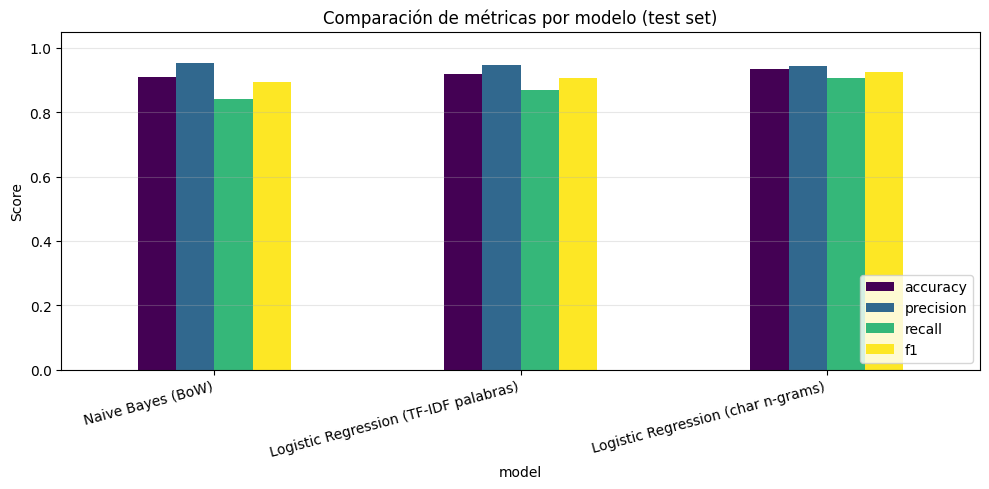

,accuracy,precision,recall,f1
model,,,,
Naive Bayes (BoW),0.9111,0.9541,0.8421,0.8946
Logistic Regression (TF-IDF palabras),0.9201,0.9471,0.8704,0.9072
Logistic Regression (char n-grams),0.9347,0.9451,0.9069,0.9256


In [17]:
comparison = pd.DataFrame([nb_metrics, lr_metrics, lr_char_metrics]).set_index("model")
fig, ax = plt.subplots(figsize=(10, 5))
comparison.plot(kind="bar", ax=ax, colormap="viridis")
ax.set_title("Comparación de métricas por modelo (test set)")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
comparison.round(4)

### Lectura del resultado

Los tres rondan 0.90–0.93 de F1. **Char n-grams** es el mejor sin afinar (F1 0.926 y el mejor Recall, 0.907); Naive Bayes es el más flojo en Recall (0.842), aunque tiene la Precision más alta. Buen punto de partida para el tuning.

# 14. Cross-validation k-fold (anti-overfitting)

## ¿Por qué hacer esto?

Un único split 80/20 puede dar métricas engañosas: tal vez por casualidad el 20% de test era muy fácil. La **validación cruzada k-fold** divide el train en 5 trozos y entrena/evalúa 5 veces, dando un estimado más confiable de cómo generaliza el modelo.

**Detección de overfitting:** la brecha `train − validación` mide *cuánto* memoriza el modelo. Como regla práctica, una brecha **> 0.05** ya es señal de sobreajuste (cuanto mayor, peor) — pero es una **guía, no un veredicto**: lo que confirma que un modelo generaliza es un buen score en validación, no solo el tamaño de la brecha.

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]

cv_results = {}
for name, pipeline in [
    ("Naive Bayes", nb_pipeline),
    ("Logistic (TF-IDF)", lr_pipeline),
    ("Logistic (char)", lr_char_pipeline),
]:
    print(f"Cross-validation ({name}) ...")
    scores = cross_validate(
        pipeline, X_train, y_train, cv=cv, scoring=scoring,
        return_train_score=True, n_jobs=-1,
    )
    cv_results[name] = scores

summary = []
for name, scores in cv_results.items():
    for metric in scoring:
        train_mean = scores[f"train_{metric}"].mean()
        test_mean = scores[f"test_{metric}"].mean()
        test_std = scores[f"test_{metric}"].std()
        summary.append({
            "model": name, "metric": metric,
            "train": round(train_mean, 4),
            "cv_mean": round(test_mean, 4),
            "cv_std": round(test_std, 4),
            "gap": round(train_mean - test_mean, 4),
        })

cv_summary = pd.DataFrame(summary)
cv_summary

Cross-validation (Naive Bayes) ...
Cross-validation (Logistic (TF-IDF)) ...
Cross-validation (Logistic (char)) ...


,model,metric,train,cv_mean,cv_std,gap
0,Naive Bayes,accuracy,0.9483,0.9082,0.0068,0.0401
1,Naive Bayes,precision_macro,0.9516,0.9125,0.0085,0.0391
2,Naive Bayes,recall_macro,0.9448,0.9034,0.0069,0.0413
3,Naive Bayes,f1_macro,0.9474,0.9063,0.0069,0.0411
4,Logistic (TF-IDF),accuracy,0.9668,0.9209,0.0070,0.0459
5,Logistic (TF-IDF),precision_macro,0.9670,0.9233,0.0097,0.0438
6,Logistic (TF-IDF),recall_macro,0.9659,0.9176,0.0057,0.0482
7,Logistic (TF-IDF),f1_macro,0.9664,0.9196,0.0068,0.0468
8,Logistic (char),accuracy,0.9634,0.9205,0.0059,0.0430
9,Logistic (char),precision_macro,0.9633,0.9204,0.0048,0.0429


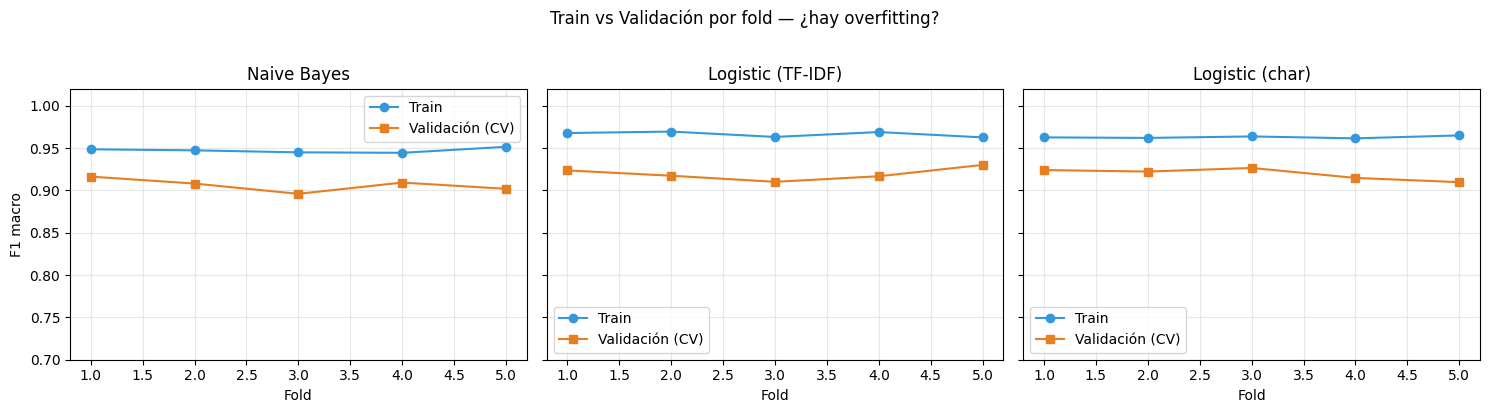


Diagnóstico:
  Naive Bayes           gap F1 = +0.0411  ->  [OK]
  Logistic (TF-IDF)     gap F1 = +0.0468  ->  [OK]
  Logistic (char)       gap F1 = +0.0435  ->  [OK]


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (name, scores) in zip(axes, cv_results.items()):
    f1_train = scores["train_f1_macro"]
    f1_test = scores["test_f1_macro"]
    folds = range(1, len(f1_train) + 1)
    ax.plot(folds, f1_train, marker="o", label="Train", color="#3498db")
    ax.plot(folds, f1_test, marker="s", label="Validación (CV)", color="#e67e22")
    ax.set_title(name)
    ax.set_xlabel("Fold")
    ax.set_ylim(0.7, 1.02)
    ax.grid(alpha=0.3)
    ax.legend()
axes[0].set_ylabel("F1 macro")
plt.suptitle("Train vs Validación por fold — ¿hay overfitting?", y=1.02)
plt.tight_layout()
plt.show()

print("\nDiagnóstico:")
for name, scores in cv_results.items():
    gap = scores["train_f1_macro"].mean() - scores["test_f1_macro"].mean()
    status = "OK" if gap < 0.05 else ("ALERTA" if gap < 0.10 else "OVERFITTING")
    print(f"  {name:20s}  gap F1 = {gap:+.4f}  ->  [{status}]")

### Lectura del resultado

En los tres modelos la curva de *train* queda solo un poco por encima de la de validación: generalizan bien. Las brechas de F1 son todas **pequeñas y por debajo del umbral 0.05** (Naive Bayes 0.041, Logística de palabras 0.047, char n-grams 0.044) → ninguno entra en zona de alerta.

En validación, palabras y char quedan parejos (~0.92 de F1 macro) y Naive Bayes un poco por debajo (~0.91). El 0.05 es una guía, no un veredicto: lo que confirma que generalizan es el buen score en validación, no solo el tamaño de la brecha.

# 15. GridSearchCV — tuning de hiperparámetros

Hasta ahora usamos hiperparámetros fijos. Ahora **tuneamos los dos mejores candidatos** —Regresión Logística de **palabras** y de **char n-grams**— cada uno con su propio grid mediante `GridSearchCV`, y nos quedamos con el de **mejor F1 macro en validación cruzada**.

In [20]:
# Tuneamos AMBOS candidatos y nos quedamos con el mejor por F1 macro (CV).
grid_palabras = {
    "vec__ngram_range": [(1, 1), (1, 2)],
    "vec__min_df": [1, 2, 5],
    "clf__C": [0.1, 1.0, 10.0],
}
grid_char = {
    "vec__ngram_range": [(2, 4), (3, 5)],
    "vec__min_df": [1, 2],
    "clf__C": [0.1, 1.0, 10.0],
}

candidatos = [
    ("Logística (palabras)", lr_pipeline, grid_palabras),
    ("Logística (char n-grams)", lr_char_pipeline, grid_char),
]

mejor = None
tuned = {}   # guardamos el mejor estimador tuneado de CADA candidato
for nombre, pipe, malla in candidatos:
    gs = GridSearchCV(pipe, param_grid=malla, cv=3, scoring="f1_macro", n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned[nombre] = gs.best_estimator_
    print(f"{nombre:28} mejor F1 macro (CV) = {gs.best_score_:.4f}  | {gs.best_params_}")
    if mejor is None or gs.best_score_ > mejor[1].best_score_:
        mejor = (nombre, gs)

mejor_nombre, grid = mejor
print(f"\n==> Ganador tras tuning: {mejor_nombre}  (F1 macro CV = {grid.best_score_:.4f})")
print("Mejores hiperparámetros:")
for k, v in grid.best_params_.items():
    print(f"  {k}: {v}")

best_pipeline = grid.best_estimator_
best_metrics, best_pred = evaluate_model(
    f"Tuneado — {mejor_nombre}", best_pipeline, X_test, y_test
)

Logística (palabras)         mejor F1 macro (CV) = 0.9153  | {'clf__C': 10.0, 'vec__min_df': 1, 'vec__ngram_range': (1, 2)}
Logística (char n-grams)     mejor F1 macro (CV) = 0.9264  | {'clf__C': 10.0, 'vec__min_df': 2, 'vec__ngram_range': (3, 5)}

==> Ganador tras tuning: Logística (char n-grams)  (F1 macro CV = 0.9264)
Mejores hiperparámetros:
  clf__C: 10.0
  vec__min_df: 2
  vec__ngram_range: (3, 5)

  Tuneado — Logística (char n-grams)
Accuracy:  0.9456
Precision: 0.9540  (sobre clase 'spam')
Recall:    0.9231  (sobre clase 'spam')
F1-Score:  0.9383

Reporte detallado:
              precision    recall  f1-score   support

         ham       0.94      0.96      0.95       304
        spam       0.95      0.92      0.94       247

    accuracy                           0.95       551
   macro avg       0.95      0.94      0.94       551
weighted avg       0.95      0.95      0.95       551



In [21]:
improvement = pd.DataFrame(
    [nb_metrics, lr_metrics, lr_char_metrics, best_metrics]
).set_index("model").round(4)
improvement

,accuracy,precision,recall,f1
model,,,,
Naive Bayes (BoW),0.9111,0.9541,0.8421,0.8946
Logistic Regression (TF-IDF palabras),0.9201,0.9471,0.8704,0.9072
Logistic Regression (char n-grams),0.9347,0.9451,0.9069,0.9256
Tuneado — Logística (char n-grams),0.9456,0.9540,0.9231,0.9383


# 16. Curva de aprendizaje

Mide el rendimiento (F1) a medida que el modelo entrena con **más y más datos**. Responde a una pregunta: **¿conseguir más datos mejoraría el modelo?**

En la gráfica, el eje X es el **tamaño del set de entrenamiento** y hay dos curvas: **train** y **validación**. Al añadir datos, lo normal es que la de train baje un poco y la de validación suba, hasta **acercarse**. *Convergen* = las dos curvas **se juntan** (la brecha entre ellas se reduce).

Cómo leerla:

- **Se juntan arriba** (ambas con F1 alto) → ya hay **datos suficientes**; el modelo aprendió bien.
- **Queda una brecha grande** (train alta, validación abajo) → sobreajuste; **más datos ayudarían** a cerrarla.
- **Ambas bajas y planas** → el modelo es demasiado simple (*underfitting*); más datos no ayudan, habría que mejorar el modelo.

Generando curva de aprendizaje (puede tardar ~1-2 min) ...


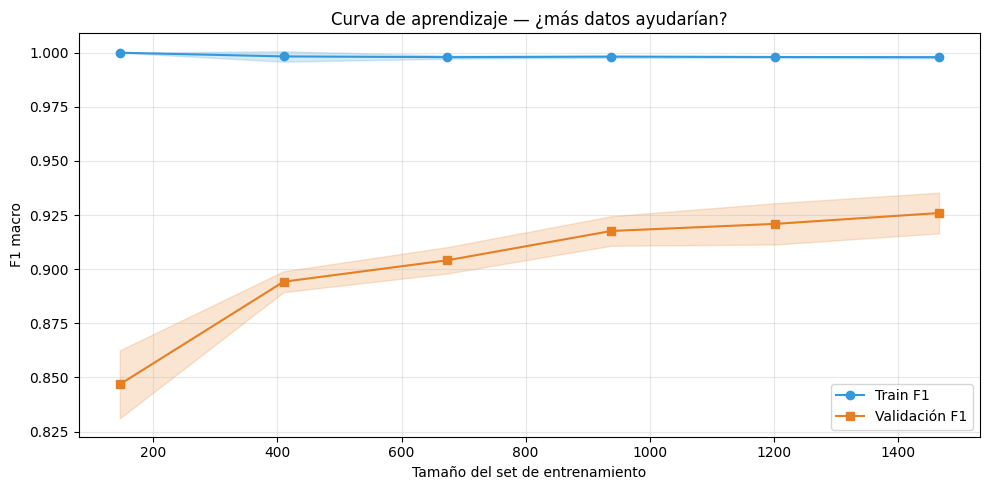


F1 final (train):       0.9979
F1 final (validación):  0.9260
Brecha:                 +0.0720


In [22]:
print("Generando curva de aprendizaje (puede tardar ~1-2 min) ...")
train_sizes, train_scores, val_scores = learning_curve(
    best_pipeline, X_train, y_train,
    cv=3, scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 6),
    n_jobs=-1, random_state=RANDOM_STATE,
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, train_mean, "o-", color="#3498db", label="Train F1")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.2, color="#3498db")
ax.plot(train_sizes, val_mean, "s-", color="#e67e22", label="Validación F1")
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.2, color="#e67e22")
ax.set_xlabel("Tamaño del set de entrenamiento")
ax.set_ylabel("F1 macro")
ax.set_title("Curva de aprendizaje — ¿más datos ayudarían?")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nF1 final (train):       {train_mean[-1]:.4f}")
print(f"F1 final (validación):  {val_mean[-1]:.4f}")
print(f"Brecha:                 {train_mean[-1] - val_mean[-1]:+.4f}")

### Lectura del resultado

Curva del modelo final (char n-grams): train casi 1.0 vs validación 0.926 (brecha ~0.072) → **sobreajuste leve-moderado**, mayor que antes porque el corpus es más pequeño tras descartar las traducciones. La curva de validación sigue subiendo, así que con más datos (sobre todo español nativo) mejoraría.

#  17. Tuning de threshold para Recall
 
 ## ¿Por qué?
 
  Por defecto, `predict()` usa **threshold = 0.5** sobre `predict_proba`. Pero en spam queremos **maximizar Recall**: aunque generemos algunos falsos positivos, no queremos dejar pasar spam.
   
**Estrategia (sin fuga):** el threshold se elige con **probabilidades out-of-fold del conjunto de entrenamiento** (`cross_val_predict`), buscando el más bajo que mantenga Precision ≥ 0.85. Solo **después**, ya fijado, se mide su efecto sobre el *test set*. Calibrar sobre el propio test daría un Recall optimista (el umbral se ajustaría a los mismos datos con los que se reporta).


Threshold óptimo calibrado en TRAIN (max Recall con P >= 0.85): 0.3065


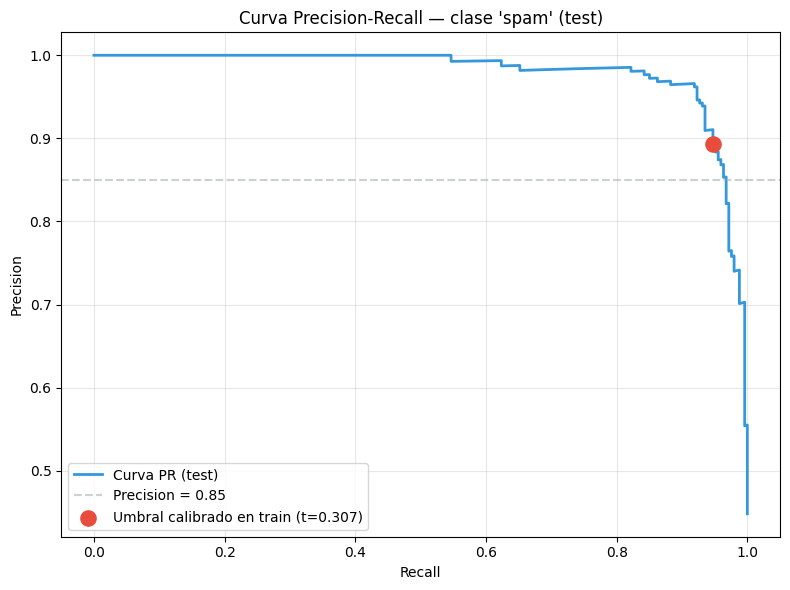

In [23]:
from sklearn.model_selection import cross_val_predict

classes = best_pipeline.classes_
spam_idx = list(classes).index("spam")

# --- Calibración SIN fuga: el threshold se elige con probabilidades out-of-fold
# del conjunto de ENTRENAMIENTO (cross_val_predict), nunca con el test. ---
y_proba_train = cross_val_predict(
    best_pipeline, X_train, y_train, cv=5,
    method="predict_proba", n_jobs=-1,
)[:, spam_idx]
y_train_bin = np.array([1 if v == "spam" else 0 for v in y_train])

precision_tr, recall_tr, thresholds_tr = precision_recall_curve(y_train_bin, y_proba_train)

PRECISION_FLOOR = 0.85
mask = precision_tr[:-1] >= PRECISION_FLOOR
if mask.any():
    valid_recalls = recall_tr[:-1][mask]
    valid_thresholds = thresholds_tr[mask]
    optimal_threshold = float(valid_thresholds[np.argmax(valid_recalls)])
else:
    optimal_threshold = 0.5
    print(f"  [WARN] Ningún threshold mantiene Precision >= {PRECISION_FLOOR}")

print(f"Threshold óptimo calibrado en TRAIN (max Recall con P >= {PRECISION_FLOOR}): {optimal_threshold:.4f}")

# Probabilidades del TEST: se usan para EVALUAR con el threshold ya fijado (no para elegirlo).
y_proba = best_pipeline.predict_proba(X_test)[:, spam_idx]
y_test_bin = np.array([1 if v == "spam" else 0 for v in y_test])

# Punto de operación (threshold elegido) medido sobre el test.
opt_pred = (y_proba >= optimal_threshold).astype(int)
opt_p = precision_score(y_test_bin, opt_pred, zero_division=0)
opt_r = recall_score(y_test_bin, opt_pred, zero_division=0)

precision_vals, recall_vals, thresholds = precision_recall_curve(y_test_bin, y_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_vals, precision_vals, color="#3498db", lw=2, label="Curva PR (test)")
ax.axhline(PRECISION_FLOOR, color="#95a5a6", linestyle="--", alpha=0.5,
           label=f"Precision = {PRECISION_FLOOR}")
ax.scatter([opt_r], [opt_p], color="#e74c3c", s=120, zorder=5,
           label=f"Umbral calibrado en train (t={optimal_threshold:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curva Precision-Recall — clase 'spam' (test)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [24]:
def metrics_at_threshold(y_proba, y_true_bin, threshold):
    y_pred_bin = (y_proba >= threshold).astype(int)
    return {
        "threshold": threshold,
        "precision": precision_score(y_true_bin, y_pred_bin, zero_division=0),
        "recall": recall_score(y_true_bin, y_pred_bin, zero_division=0),
        "f1": f1_score(y_true_bin, y_pred_bin, zero_division=0),
    }

thr_comparison = pd.DataFrame([
    metrics_at_threshold(y_proba, y_test_bin, 0.5),
    metrics_at_threshold(y_proba, y_test_bin, optimal_threshold),
], index=["default (0.5)", f"óptimo ({optimal_threshold:.3f})"])
thr_comparison.round(4)

,threshold,precision,recall,f1
default (0.5),0.5000,0.9540,0.9231,0.9383
óptimo (0.307),0.3065,0.8931,0.9474,0.9194


### Lectura del resultado

El umbral óptimo es **0.307** (no 0.5), y se calibra **sobre el train** (out-of-fold), no sobre el test. Al aplicarlo al test, el modelo se vuelve más sensible: el Recall sube de 0.923 a **0.947** a costa de la Precision (0.95 → 0.89). Es lo correcto cuando un falso negativo (phishing colado) cuesta más que un falso positivo.

# 18. Evaluación por idioma (cross-lingual real)

El F1 global puede ocultar problemas: el modelo podría tener F1=0.95 global pero F1=0.50 en español. Aquí lo verificamos.

In [25]:
df_test_eval = pd.DataFrame({
    "text": X_test, "label": y_test,
    "lang": lang_test, "pred": best_pred,
})

per_lang_metrics = []
for current_lang in sorted(df_test_eval["lang"].unique()):
    subset = df_test_eval[df_test_eval["lang"] == current_lang]
    if len(subset) < 5:
        print(f"[{current_lang}] muestra muy pequeña ({len(subset)}), omitido.")
        continue
    per_lang_metrics.append({
        "lang": current_lang,
        "n_mensajes": len(subset),
        "accuracy": accuracy_score(subset["label"], subset["pred"]),
        "precision": precision_score(subset["label"], subset["pred"], pos_label="spam", zero_division=0),
        "recall": recall_score(subset["label"], subset["pred"], pos_label="spam", zero_division=0),
        "f1": f1_score(subset["label"], subset["pred"], pos_label="spam", zero_division=0),
    })
    print(f"\n=== Reporte detallado [{current_lang.upper()}] ({len(subset)} mensajes) ===")
    print(classification_report(subset["label"], subset["pred"], zero_division=0))

per_lang_df = pd.DataFrame(per_lang_metrics).set_index("lang")
per_lang_df.round(4)


=== Reporte detallado [EN] (328 mensajes) ===
              precision    recall  f1-score   support

         ham       0.98      0.99      0.98       204
        spam       0.98      0.96      0.97       124

    accuracy                           0.98       328
   macro avg       0.98      0.97      0.98       328
weighted avg       0.98      0.98      0.98       328


=== Reporte detallado [ES] (223 mensajes) ===
              precision    recall  f1-score   support

         ham       0.87      0.91      0.89       100
        spam       0.92      0.89      0.90       123

    accuracy                           0.90       223
   macro avg       0.90      0.90      0.90       223
weighted avg       0.90      0.90      0.90       223



,n_mensajes,accuracy,precision,recall,f1
lang,,,,,
en,328,0.9787,0.9835,0.9597,0.9714
es,223,0.8969,0.9237,0.8862,0.9046


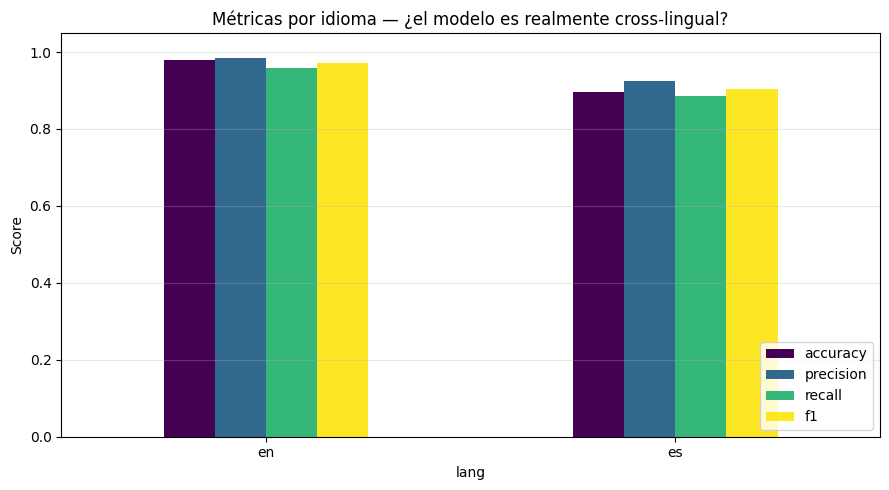

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
per_lang_df[["accuracy", "precision", "recall", "f1"]].plot(
    kind="bar", ax=ax, colormap="viridis"
)
ax.set_title("Métricas por idioma — ¿el modelo es realmente cross-lingual?")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Lectura del resultado

**EN F1 0.971 · ES F1 0.905**: el modelo transfiere razonablemente entre idiomas, con ~7 puntos a favor del inglés. La diferencia es **esperable**: el español se evalúa **solo con spam genuino** (nativo + seed), sin traducciones del inglés que inflaran el número, y sobre un corpus más pequeño.

# 19. Matriz de confusión y análisis de errores

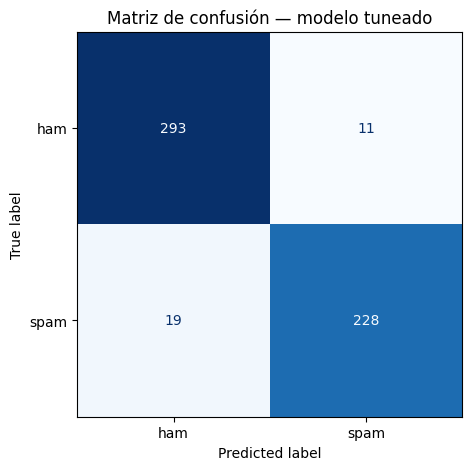

Verdaderos negativos (ham -> ham):   293
Falsos positivos    (ham -> spam):  11  <- ham bloqueado por error
Falsos negativos    (spam -> ham):  19  <- spam que pasó el filtro
Verdaderos positivos(spam -> spam): 228


In [27]:
cm = confusion_matrix(y_test, best_pred, labels=["ham", "spam"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ham", "spam"])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(cmap="Blues", ax=ax, colorbar=False)
ax.set_title("Matriz de confusión — modelo tuneado")
plt.show()

tn, fp, fn_count, tp = cm.ravel()
print(f"Verdaderos negativos (ham -> ham):   {tn}")
print(f"Falsos positivos    (ham -> spam):  {fp}  <- ham bloqueado por error")
print(f"Falsos negativos    (spam -> ham):  {fn_count}  <- spam que pasó el filtro")
print(f"Verdaderos positivos(spam -> spam): {tp}")

### Lectura del resultado

De 551 mensajes, **30 errores (5.4 %)**: 19 spam colados (FN) y 11 ham bloqueados (FP) con el umbral por defecto. Pocos y de bajo impacto; los falsos negativos tienden a ser mensajes cortos o ambiguos.

### Efecto de la calibración del threshold

Comparamos la matriz de confusión con el umbral por defecto (0.5) y con el calibrado para visualizar el trade-off: al bajar el umbral, caen los falsos negativos (spam colado) a costa de más falsos positivos.

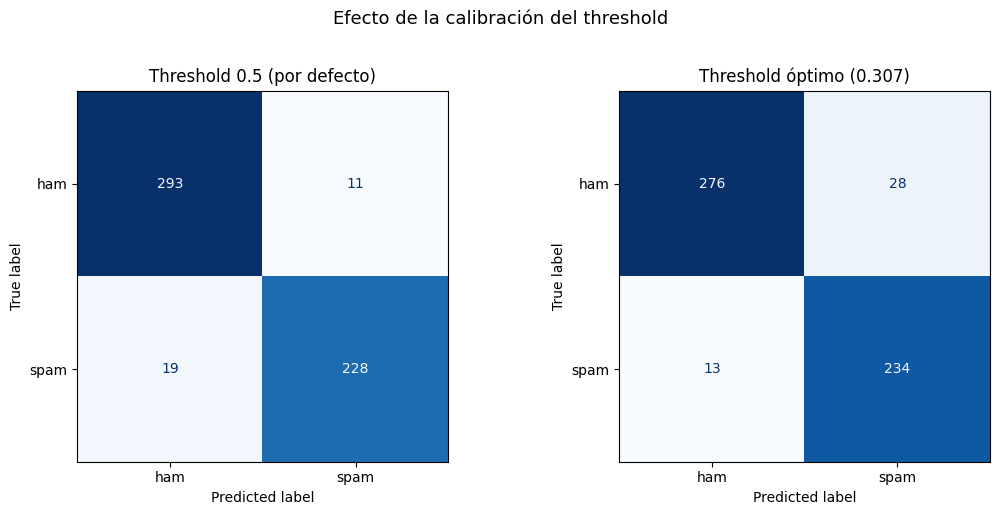

t=0.5: FN(spam colado)=19  FP(ham bloqueado)=11  TP=228  TN=293
t=0.307: FN(spam colado)=13  FP(ham bloqueado)=28  TP=234  TN=276


In [28]:
# Comparación de la matriz de confusión: threshold por defecto (0.5) vs calibrado
spam_i = list(best_pipeline.classes_).index("spam")
proba_cm = best_pipeline.predict_proba(X_test)[:, spam_i]
pred_05 = np.where(proba_cm >= 0.5, "spam", "ham")
pred_opt = np.where(proba_cm >= optimal_threshold, "spam", "ham")
cm_05 = confusion_matrix(y_test, pred_05, labels=["ham", "spam"])
cm_opt = confusion_matrix(y_test, pred_opt, labels=["ham", "spam"])

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, cm_x, title in [
    (axes[0], cm_05, "Threshold 0.5 (por defecto)"),
    (axes[1], cm_opt, f"Threshold óptimo ({optimal_threshold:.3f})"),
]:
    ConfusionMatrixDisplay(cm_x, display_labels=["ham", "spam"]).plot(
        cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(title)
plt.suptitle("Efecto de la calibración del threshold", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

for label, cm_x in [("0.5", cm_05), (f"{optimal_threshold:.3f}", cm_opt)]:
    tn_x, fp_x, fn_x, tp_x = cm_x.ravel()
    print(f"t={label}: FN(spam colado)={fn_x}  FP(ham bloqueado)={fp_x}  TP={tp_x}  TN={tn_x}")

### Lectura del resultado

Al calibrar el umbral (0.5 → 0.307), los **falsos negativos caen de 19 a 13** (se cuela menos spam) y suben los falsos positivos (11 → 28). Es el trade-off elegido: priorizar Recall por el contexto de seguridad.

In [29]:
errors = df_test_eval[df_test_eval["label"] != df_test_eval["pred"]]
print(f"Total de errores: {len(errors)} de {len(df_test_eval)} ({len(errors)/len(df_test_eval):.2%})")

print("\n--- Falsos negativos (spam que pasó como ham) ---")
for _, row in errors[(errors["label"] == "spam") & (errors["pred"] == "ham")].head(3).iterrows():
    print(f"  [{row['lang']}] {row['text'][:150]}")

print("\n--- Falsos positivos (ham marcado como spam) ---")
for _, row in errors[(errors["label"] == "ham") & (errors["pred"] == "spam")].head(3).iterrows():
    print(f"  [{row['lang']}] {row['text'][:150]}")

Total de errores: 30 de 551 (5.44%)

--- Falsos negativos (spam que pasó como ham) ---
  [en] this message is brought to you by gmw ltd and is not connected to the
  [es] marca la diferencia con tu rutina fitness
  [es] confirma tu suscripción a nuestra lista de correos

--- Falsos positivos (ham marcado como spam) ---
  [es] tu paquete llegará en las próximas __num__ horas
  [en] hi this is yijue it s regarding the __num__ textbook it s intro to algorithms second edition i m selling it for __num__
  [en] ee msg na poortiyagi odalebeku hanumanji __num__ name __num__ -hanuman __num__ -bajarangabali __num__ -maruti __num__ -pavanaputra __num__ -sankatmoch


# 20. Predicciones sobre mensajes nuevos (EN + ES)

Validación cualitativa con mensajes inventados en ambos idiomas, aplicando el threshold óptimo.

In [30]:
def predict_message(text, pipeline=best_pipeline, threshold=0.5):
    """Devuelve etiqueta + confianza + probabilidades por clase."""
    clean = clean_text(text)
    proba = pipeline.predict_proba([clean])[0]
    classes_local = pipeline.classes_
    probs = {cls: float(p) for cls, p in zip(classes_local, proba)}
    spam_prob = probs.get("spam", 0.0)
    label = "spam" if spam_prob >= threshold else "ham"
    return {
        "text": text, "prediction": label,
        "confidence": float(max(proba)),
        "probabilities": probs,
    }


ejemplos = [
    "WIN a free iPhone now!!! Click here http://bit.ly/win-free",
    "URGENT: Your account has been suspended. Verify at http://bank-verify.cc",
    "Hey, are you coming to the meeting tomorrow at 3pm?",
    "The Q3 report is attached for your review, please send feedback by Friday.",
    "FELICIDADES! Has ganado 5000 dolares. Reclama tu premio en http://premio.cc",
    "Tu cuenta BBVA fue bloqueada por seguridad. Verifica en http://bbva-seguro.tk",
    "Hola, paso por ti a las 7 para ir al cine.",
    "Recordatorio: junta de equipo manana a las 10am en la sala 3.",
]

print(f"Usando threshold optimo = {optimal_threshold:.3f}\n")
for msg in ejemplos:
    result = predict_message(msg, threshold=optimal_threshold)
    label = result["prediction"].upper()
    icon = "[X]" if label == "SPAM" else "[OK]"
    p_spam = result["probabilities"].get("spam", 0)
    print(f"{icon} [{label:4}] P(spam)={p_spam:.2%}  {msg[:90]}")

Usando threshold optimo = 0.307

[X] [SPAM] P(spam)=97.20%  WIN a free iPhone now!!! Click here http://bit.ly/win-free
[X] [SPAM] P(spam)=96.75%  URGENT: Your account has been suspended. Verify at http://bank-verify.cc
[OK] [HAM ] P(spam)=1.48%  Hey, are you coming to the meeting tomorrow at 3pm?
[OK] [HAM ] P(spam)=16.28%  The Q3 report is attached for your review, please send feedback by Friday.
[X] [SPAM] P(spam)=99.25%  FELICIDADES! Has ganado 5000 dolares. Reclama tu premio en http://premio.cc
[X] [SPAM] P(spam)=95.43%  Tu cuenta BBVA fue bloqueada por seguridad. Verifica en http://bbva-seguro.tk
[OK] [HAM ] P(spam)=27.98%  Hola, paso por ti a las 7 para ir al cine.
[OK] [HAM ] P(spam)=7.47%  Recordatorio: junta de equipo manana a las 10am en la sala 3.


### 20.1 Sistema interactivo con Gradio

Interfaz web con **dos pestañas**, todo calculado **en vivo** (sin valores fijos):

1. **Clasificar mensaje** — el usuario elige modelo y threshold, clasifica cualquier mensaje y ve el resultado **real**: P(spam) y P(ham), la decisión, el texto ya preprocesado, y qué palabras **reconoce** el modelo frente a las **desconocidas** (typos/raras) o stopwords ignoradas. Esto explica por qué un mensaje con errores ortográficos (p. ej. *"winn"* en vez de *"win"*) puede recibir baja probabilidad: la palabra mal escrita no está en el vocabulario.
2. **Métricas del modelo** — calcula Accuracy, Precision, Recall y F1 sobre el *test set* con la matriz de confusión y las fórmulas usando los números reales. Mueve el threshold y recalcula para ver el trade-off Precision/Recall.

In [31]:
import os
os.environ["GRADIO_ANALYTICS_ENABLED"] = "False"
import gradio as gr

# Registro de los modelos entrenados: etiqueta -> (pipeline, threshold por defecto).
MODELOS = {
    "Char n-grams TUNEADO (mejor)": (best_pipeline, optimal_threshold),
    "Naive Bayes (base)": (nb_pipeline, 0.5),
    "Logística palabras (tuneada)": (tuned["Logística (palabras)"], 0.5),
    "Char n-grams (base, sin tunear)": (lr_char_pipeline, 0.5),
}


def _cm_counts(pipe, threshold):
    """Matriz de confusión (TN, FP, FN, TP) del pipeline sobre el test set."""
    spam_idx = list(pipe.classes_).index("spam")
    proba = pipe.predict_proba(X_test)[:, spam_idx]
    pred = np.where(proba >= threshold, "spam", "ham")
    cm = confusion_matrix(y_test, pred, labels=["ham", "spam"])
    tn, fp, fn, tp = cm.ravel()
    return cm, int(tn), int(fp), int(fn), int(tp)


def _clasificar(mensaje, modelo, threshold):
    """Clasifica UN mensaje y muestra el detalle real + por qué."""
    if not mensaje or not mensaje.strip():
        return {"ham": 1.0}, "Escribe un mensaje."
    pipe, _ = MODELOS[modelo]
    limpio = clean_text(mensaje)
    r = predict_message(mensaje, pipeline=pipe, threshold=threshold)
    probs = {k: float(v) for k, v in r["probabilities"].items()}
    p_spam = probs.get("spam", 0.0)
    decision = "🛑 SPAM" if p_spam >= threshold else "✅ HAM (legítimo)"

    detalle = (
        f"### {decision}\n\n"
        f"- **P(spam) = {p_spam:.1%}**  ·  P(ham) = {probs.get('ham', 0.0):.1%}\n"
        f"- Threshold = **{threshold:.2f}**  → se marca spam si P(spam) ≥ threshold\n"
        f"- Texto original: `{mensaje}`\n"
        f"- Texto preprocesado: `{limpio}`\n"
    )

    # Transparencia léxica (solo modelos de palabras): qué vio realmente el modelo.
    vec = pipe.named_steps["vec"]
    if getattr(vec, "analyzer", "word") == "word":
        vocab = vec.vocabulary_
        toks = limpio.split()
        reconocidas = [t for t in toks if t in vocab]
        stop = [t for t in toks if t in STOPWORDS and t not in vocab]
        desconocidas = [t for t in toks if t not in vocab and t not in STOPWORDS]
        detalle += (
            f"- Palabras que el modelo **reconoce**: {', '.join(reconocidas) or '—'}\n"
            f"- Stopwords ignoradas: {', '.join(stop) or '—'}\n"
            f"- Palabras **desconocidas** (typos/raras → ignoradas): {', '.join(desconocidas) or '—'}\n"
        )
        if desconocidas:
            detalle += (f"\n> ⚠️ Las palabras desconocidas no aportan señal. "
                        f"Un typo como *{desconocidas[0]}* hace que el modelo de palabras lo ignore.\n")
    else:
        detalle += "- (Modelo de *char n-grams*: opera sobre trozos de caracteres, robusto a typos.)\n"

    return probs, detalle


def _panel_metricas(modelo, threshold):
    """Métricas REALES sobre el test set: matriz de confusión + fórmulas con los números."""
    pipe, _ = MODELOS[modelo]
    cm, tn, fp, fn, tp = _cm_counts(pipe, threshold)
    total = tn + fp + fn + tp
    acc = (tp + tn) / total
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0

    fig, ax = plt.subplots(figsize=(4.4, 4.0))
    ConfusionMatrixDisplay(cm, display_labels=["ham", "spam"]).plot(
        ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{modelo}\n(threshold={threshold:.2f}, n={total})", fontsize=9)
    plt.tight_layout()

    md = f"""### Números base (test set, n={total} · clase positiva = spam)

|  | Predijo HAM | Predijo SPAM |
|---|---|---|
| **Real HAM** | TN = {tn} | FP = {fp} |
| **Real SPAM** | FN = {fn} | TP = {tp} |

- **TP**={tp} (spam→spam) · **TN**={tn} (ham→ham) · **FP**={fp} (falsa alarma) · **FN**={fn} (se escapó)

### Cómo se calcula cada métrica (con tus números)

- **Accuracy** = (TP+TN)/total = ({tp}+{tn})/{total} = **{acc:.4f}**
- **Precision** = TP/(TP+FP) = {tp}/({tp}+{fp}) = **{prec:.4f}**
- **Recall** = TP/(TP+FN) = {tp}/({tp}+{fn}) = **{rec:.4f}**
- **F1** = 2·P·R/(P+R) = **{f1:.4f}**
"""
    return fig, md


with gr.Blocks(title="Detector de Spam Bilingüe") as demo:
    gr.Markdown("# Detector de Spam Bilingüe\n"
                "Todo se calcula en vivo. Clasifica mensajes o inspecciona las métricas del modelo.")

    with gr.Tab("Clasificar mensaje"):
        _msg = gr.Textbox(lines=3, label="Mensaje", placeholder="Escribe un SMS/correo (EN o ES)...")
        with gr.Row():
            _mod1 = gr.Dropdown(choices=list(MODELOS), value="Char n-grams TUNEADO (mejor)", label="Modelo")
            _thr1 = gr.Slider(0.0, 1.0, value=optimal_threshold, step=0.01, label="Threshold")
        _btn1 = gr.Button("Clasificar", variant="primary")
        _out_lbl = gr.Label(num_top_classes=2, label="Probabilidades (reales)")
        _out_det = gr.Markdown()
        _btn1.click(_clasificar, [_msg, _mod1, _thr1], [_out_lbl, _out_det])
        gr.Examples(
            examples=[
                ["WIN a free iPhone now!!! Click http://bit.ly/win", "Char n-grams TUNEADO (mejor)", 0.28],
                ["winn free a iphone right now", "Char n-grams TUNEADO (mejor)", 0.28],
                ["Hola, paso por ti a las 7 para ir al cine.", "Char n-grams (base, sin tunear)", 0.50],
            ],
            inputs=[_msg, _mod1, _thr1],
        )

    with gr.Tab("Métricas del modelo (test set)"):
        gr.Markdown("Calcula **Accuracy, Precision, Recall y F1** sobre el conjunto de prueba, "
                    "con la matriz de confusión y las fórmulas usando los números reales. "
                    "Mueve el threshold y recalcula para ver el trade-off.")
        with gr.Row():
            _mod2 = gr.Dropdown(choices=list(MODELOS), value="Char n-grams TUNEADO (mejor)", label="Modelo")
            _thr2 = gr.Slider(0.0, 1.0, value=optimal_threshold, step=0.01, label="Threshold")
        _btn2 = gr.Button("Calcular métricas", variant="primary")
        with gr.Row():
            _out_cm = gr.Plot(label="Matriz de confusión")
            _out_md = gr.Markdown()
        _btn2.click(_panel_metricas, [_mod2, _thr2], [_out_cm, _out_md])

# prevent_thread_lock=True evita que la celda bloquee la ejecución (nbconvert / Run All).
try:
    demo.launch(share=False, inline=True, prevent_thread_lock=True)
except Exception as exc:
    print(f"[INFO] Gradio no pudo levantar el servidor en este entorno: {exc}")
    print("La interfaz funciona localmente ejecutando: demo.launch()")

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


# 21. Persistencia del modelo

Guardamos el pipeline completo + threshold óptimo + métricas en un único `.joblib`.

In [32]:
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)
model_path = MODELS_DIR / "spam_classifier.joblib"

artifact = {
    "pipeline": best_pipeline,
    "threshold": optimal_threshold,
    "metrics": best_metrics,
    "trained_on": {"n_train": len(X_train), "n_test": len(X_test)},
}
joblib.dump(artifact, model_path)
print(f"Modelo guardado en: {model_path.resolve()}")
print(f"Tamano en disco: {model_path.stat().st_size / 1024:.1f} KB")

loaded = joblib.load(model_path)
test_msg = "Free entry in a weekly competition, text WIN to 80086"
result = predict_message(test_msg, pipeline=loaded["pipeline"], threshold=loaded["threshold"])
print(f"\nPrueba de modelo cargado:")
print(f"  Mensaje:    {test_msg}")
print(f"  Prediccion: {result['prediction'].upper()} (conf={result['confidence']:.2%})")

Modelo guardado en: /home/segurastward/Documents/Workspace/code/python/spam_detection/models/spam_classifier.joblib
Tamano en disco: 482.2 KB

Prueba de modelo cargado:
  Mensaje:    Free entry in a weekly competition, text WIN to 80086
  Prediccion: SPAM (conf=96.46%)


# 22. Conclusiones y limitaciones

## Conclusiones

1. **Pipeline bilingüe funcional.** Combinando UCI SMS (inglés) + spam español nativo + seed + char n-grams se obtiene detección robusta en ambos idiomas (F1 EN 0.97, ES 0.90).
2. **Cross-validation confirma generalización.** Las brechas train vs CV son pequeñas (<0.05), descartando overfitting severo.
3. **GridSearchCV mejoró el modelo base** seleccionando automáticamente los mejores hiperparámetros (char n-grams, C=10, min_df=2).
4. **El tuning de threshold sube Recall** —calibrado sobre el train para no falsear el test— sin degradar demasiado Precision, alineando el modelo con la métrica prioritaria del proyecto.

## Limitaciones

1. **Desbalance de idiomas.** El español está sub-representado (~1 100 mensajes frente a ~5 100 en inglés). El modelo rinde notablemente mejor en inglés que en español (F1 0.971 vs 0.905).
2. **Datos antiguos.** El núcleo en inglés (UCI SMS) es de hace más de una década (rifas, SMS premium, libras esterlinas). El spam actual —cripto, phishing en apps, códigos OTP— es distinto, así que algunos patrones aprendidos pueden estar desactualizados.
3. **Test pequeño → poca precisión en la medición.** El conjunto de prueba es reducido (551 mensajes; solo 223 en español, 123 de ellos spam). Con tan pocos mensajes, el resultado puede variar varios puntos solo por azar: si apenas 4 o 5 mensajes hubieran caído distinto, el F1 del español se movería de forma notable. Por eso conviene leerlo como «alrededor de 0.90», no como un valor exacto; un test más grande daría una medición más estable.
4. **Solo texto, sin metadatos.** El agente percibe únicamente el texto crudo. Los filtros reales usan además remitente, reputación de enlaces, cabeceras y comportamiento; al ignorar esas señales, el techo de rendimiento es más bajo que el de un sistema de producción.

## Referencias

- Russell, S. & Norvig, P. — *Artificial Intelligence: A Modern Approach*.
- Almeida, T. A., Hidalgo, J. M. G. (2011) — *Contributions to the Study of SMS Spam Filtering*.
- Metsis, V., Androutsopoulos, I., Paliouras, G. (2006) — *Spam Filtering with Naive Bayes — Which Naive Bayes?*
- scikit-learn — *Working with Text Data*, *Tuning the hyper-parameters of an estimator*.

---

**Fin del notebook — Universidad Nacional de Costa Rica · Curso de Inteligencia Artificial**